In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
from rich.progress import Progress
from rich.console import Console
import sys
import datetime

df = pd.read_csv('data/dyson.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5028527 entries, 0 to 5028526
Data columns (total 30 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   COMPANY                object 
 1   LOCATION               object 
 2   MOLD                   object 
 3   MOLD_ID                int64  
 4   CI                     object 
 5   CT                     int64  
 6   FST                    int64  
 7   LST                    int64  
 8   YEAR                   int64  
 9   MONTH                  int64  
 10  QUARTER                int64  
 11  WEEK                   int64  
 12  DAY                    int64  
 13  UPTIME_SECONDS         int64  
 14  SHOT_COUNT             int64  
 15  CONTRACTED_CYCLE_TIME  float64
 16  CYCLE_TIME_LIMIT1      int64  
 17  CYCLE_TIME_LIMIT1UNIT  object 
 18  CYCLE_TIME_LIMIT2      int64  
 19  CYCLE_TIME_LIMIT2UNIT  object 
 20  L1_ABOVE_ADJUSTED      float64
 21  L1_BELOW_ADJUSTED      float64
 22  L2_ABOVE_ADJUSTED 

In [2]:
# lets start from the beginning and clean the missing values in the data
print(df.isnull().sum())    

COMPANY                  23524
LOCATION                     0
MOLD                         0
MOLD_ID                      0
CI                           0
CT                           0
FST                          0
LST                          0
YEAR                         0
MONTH                        0
QUARTER                      0
WEEK                         0
DAY                          0
UPTIME_SECONDS               0
SHOT_COUNT                   0
CONTRACTED_CYCLE_TIME    53332
CYCLE_TIME_LIMIT1            0
CYCLE_TIME_LIMIT1UNIT        0
CYCLE_TIME_LIMIT2            0
CYCLE_TIME_LIMIT2UNIT        0
L1_ABOVE_ADJUSTED        53332
L1_BELOW_ADJUSTED        53332
L2_ABOVE_ADJUSTED        53332
L2_BELOW_ADJUSTED        53332
ABOVE                        0
WITHIN                       0
BELOW                        0
PRODUCTION_TIME              0
BREAK_TIME                   0
UPTIME_PERCENTAGE            0
dtype: int64


In [3]:
# Filter the DataFrame for the specified companies
companies = ['IMP', 'Inyector', 'Aceway', 'San Diego Ace']
df_filtered = df[df['COMPANY'].isin(companies)]

# Check the first few rows of the filtered DataFrame
print(df_filtered.head())

# If you'd like to further inspect the number of records for each company
print(df_filtered['COMPANY'].value_counts())


       COMPANY  LOCATION     MOLD   MOLD_ID             CI   CT  \
9693  Inyector  Inyector  T127787  40551066  NCM2141I01106  396   
9694  Inyector  Inyector  T127787  40551066  NCM2141I01106  396   
9695  Inyector  Inyector  T127787  40551066  NCM2141I01106  396   
9696  Inyector  Inyector  T127787  40551066  NCM2141I01106  396   
9697  Inyector  Inyector  T127787  40551066  NCM2141I01106  396   

                 FST             LST  YEAR   MONTH  ...  L1_ABOVE_ADJUSTED  \
9693  20220807010000  20220807020000  2022  202208  ...              339.9   
9694  20220807060000  20220807070000  2022  202208  ...              339.9   
9695  20220807160000  20220807170000  2022  202208  ...              339.9   
9696  20220807210000  20220807220000  2022  202208  ...              339.9   
9697  20220807070000  20220807080000  2022  202208  ...              339.9   

      L1_BELOW_ADJUSTED  L2_ABOVE_ADJUSTED  L2_BELOW_ADJUSTED  ABOVE  WITHIN  \
9693              320.1              339.9      

In [4]:
# Separate numeric and categorical columns
numeric_cols = df_filtered.select_dtypes(include=['number']).columns
categorical_cols = df_filtered.select_dtypes(include=['object']).columns

# Fill missing values for numeric columns with the median
df_filtered[numeric_cols] = df_filtered[numeric_cols].fillna(df_filtered[numeric_cols].median())

# Fill missing values for categorical columns with the mode
df_filtered[categorical_cols] = df_filtered[categorical_cols].fillna(df_filtered[categorical_cols].mode().iloc[0])

# Check if any missing values remain
print("\nMissing values after cleaning:")
print(df_filtered.isnull().sum())

# Convert dates to datetime format
df_filtered['FST'] = pd.to_datetime(df_filtered['FST'], unit='s', errors='coerce')
df_filtered['LST'] = pd.to_datetime(df_filtered['LST'], unit='s', errors='coerce')

# Create new columns from the dates
df_filtered['FST_DATE'] = df_filtered['FST'].dt.date
df_filtered['LST_DATE'] = df_filtered['LST'].dt.date
df_filtered['FST_YEAR'] = df_filtered['FST'].dt.year
df_filtered['LST_YEAR'] = df_filtered['LST'].dt.year
df_filtered['FST_MONTH'] = df_filtered['FST'].dt.month
df_filtered['LST_MONTH'] = df_filtered['LST'].dt.month
df_filtered['FST_WEEK'] = df_filtered['FST'].dt.weekday
df_filtered['LST_WEEK'] = df_filtered['LST'].dt.weekday

# Finding outliers and removing them
print(df_filtered.describe())
print(df_filtered.info())


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_12079/3615409477.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[numeric_cols] = df_filtered[numeric_cols].fillna(df_filtered[numeric_cols].median())
/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_12079/3615409477.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[categorical_cols] = df_filtered[categorical_cols].fillna(df_filtered[categorical_cols].mode().iloc[0])
/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000


Missing values after cleaning:
COMPANY                  0
LOCATION                 0
MOLD                     0
MOLD_ID                  0
CI                       0
CT                       0
FST                      0
LST                      0
YEAR                     0
MONTH                    0
QUARTER                  0
WEEK                     0
DAY                      0
UPTIME_SECONDS           0
SHOT_COUNT               0
CONTRACTED_CYCLE_TIME    0
CYCLE_TIME_LIMIT1        0
CYCLE_TIME_LIMIT1UNIT    0
CYCLE_TIME_LIMIT2        0
CYCLE_TIME_LIMIT2UNIT    0
L1_ABOVE_ADJUSTED        0
L1_BELOW_ADJUSTED        0
L2_ABOVE_ADJUSTED        0
L2_BELOW_ADJUSTED        0
ABOVE                    0
WITHIN                   0
BELOW                    0
PRODUCTION_TIME          0
BREAK_TIME               0
UPTIME_PERCENTAGE        0
dtype: int64


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_12079/3615409477.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['LST'] = pd.to_datetime(df_filtered['LST'], unit='s', errors='coerce')
/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_12079/3615409477.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['FST_DATE'] = df_filtered['FST'].dt.date
/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_12079/3615409477.py:21: SettingWithCopyWarning: 
A value is

            MOLD_ID             CT  FST  LST           YEAR          MONTH  \
count  5.523920e+05  552392.000000    0    0  552392.000000  552392.000000   
mean   3.661125e+07     458.610454  NaT  NaT    2023.260243  202332.825150   
min    3.252533e+07       2.000000  NaT  NaT    1903.000000  190305.000000   
25%    3.430004e+07     336.000000  NaT  NaT    2023.000000  202303.000000   
50%    3.430492e+07     435.000000  NaT  NaT    2023.000000  202311.000000   
75%    4.054814e+07     549.000000  NaT  NaT    2024.000000  202405.000000   
max    1.617567e+08    5996.000000  NaT  NaT    2024.000000  202411.000000   
std    1.131544e+07     245.193014  NaN  NaN       0.942469      93.037974   

             QUARTER           WEEK           DAY  UPTIME_SECONDS  ...  \
count  552392.000000  552392.000000  5.523920e+05    5.523920e+05  ...   
mean   202328.636843  202353.817338  2.023330e+07    3.178458e+03  ...   
min    190302.000000  190320.000000  1.903052e+07    0.000000e+00  ...   
2

<Figure size 1500x1000 with 0 Axes>

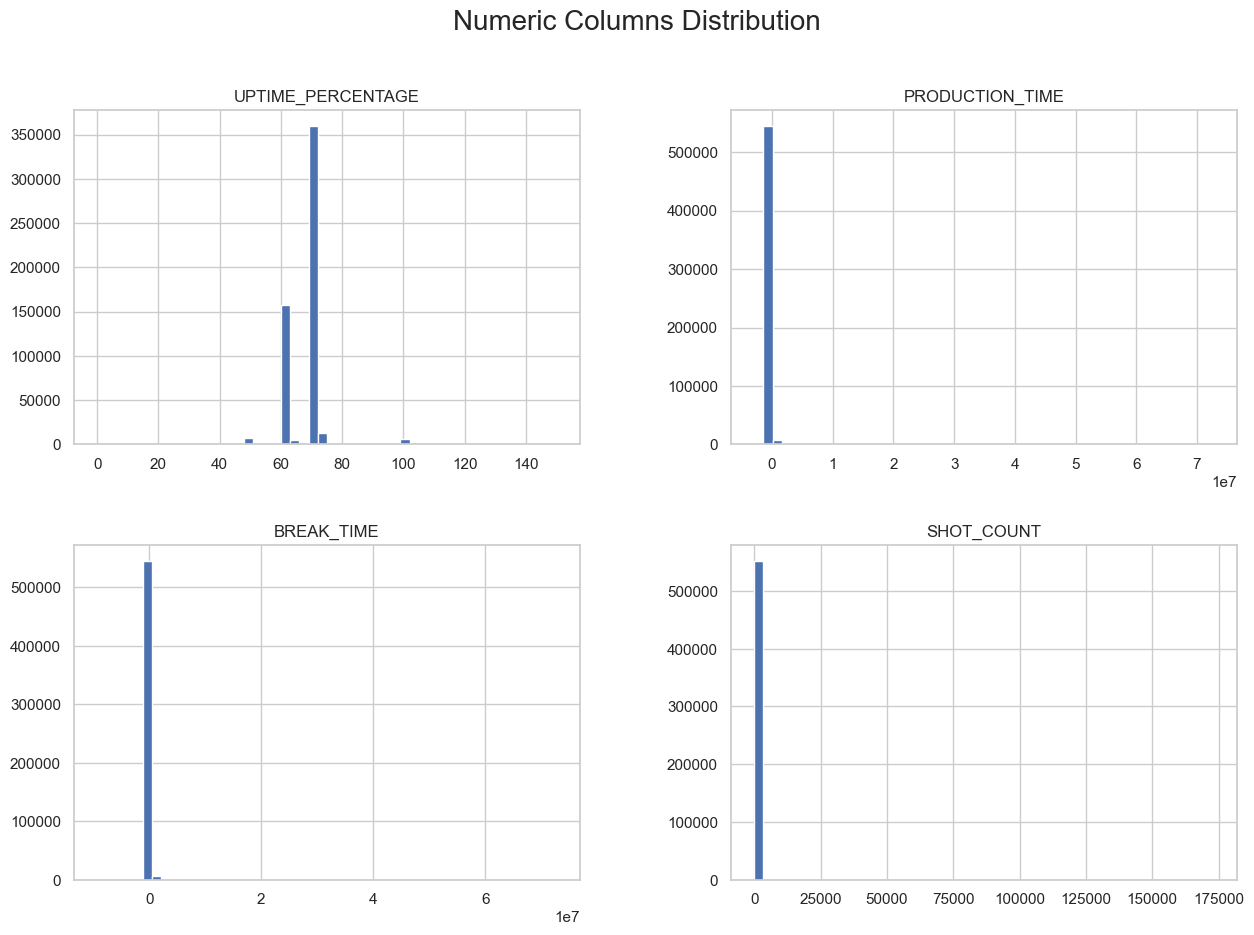

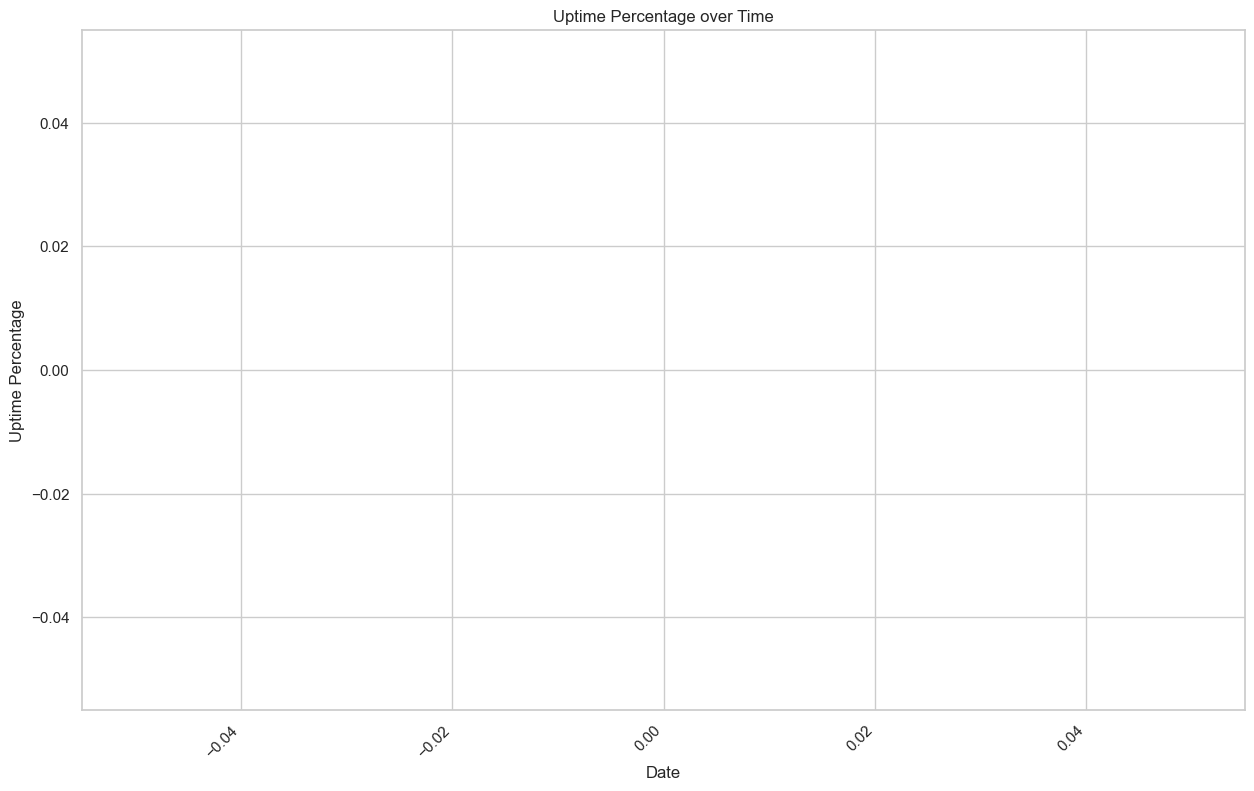

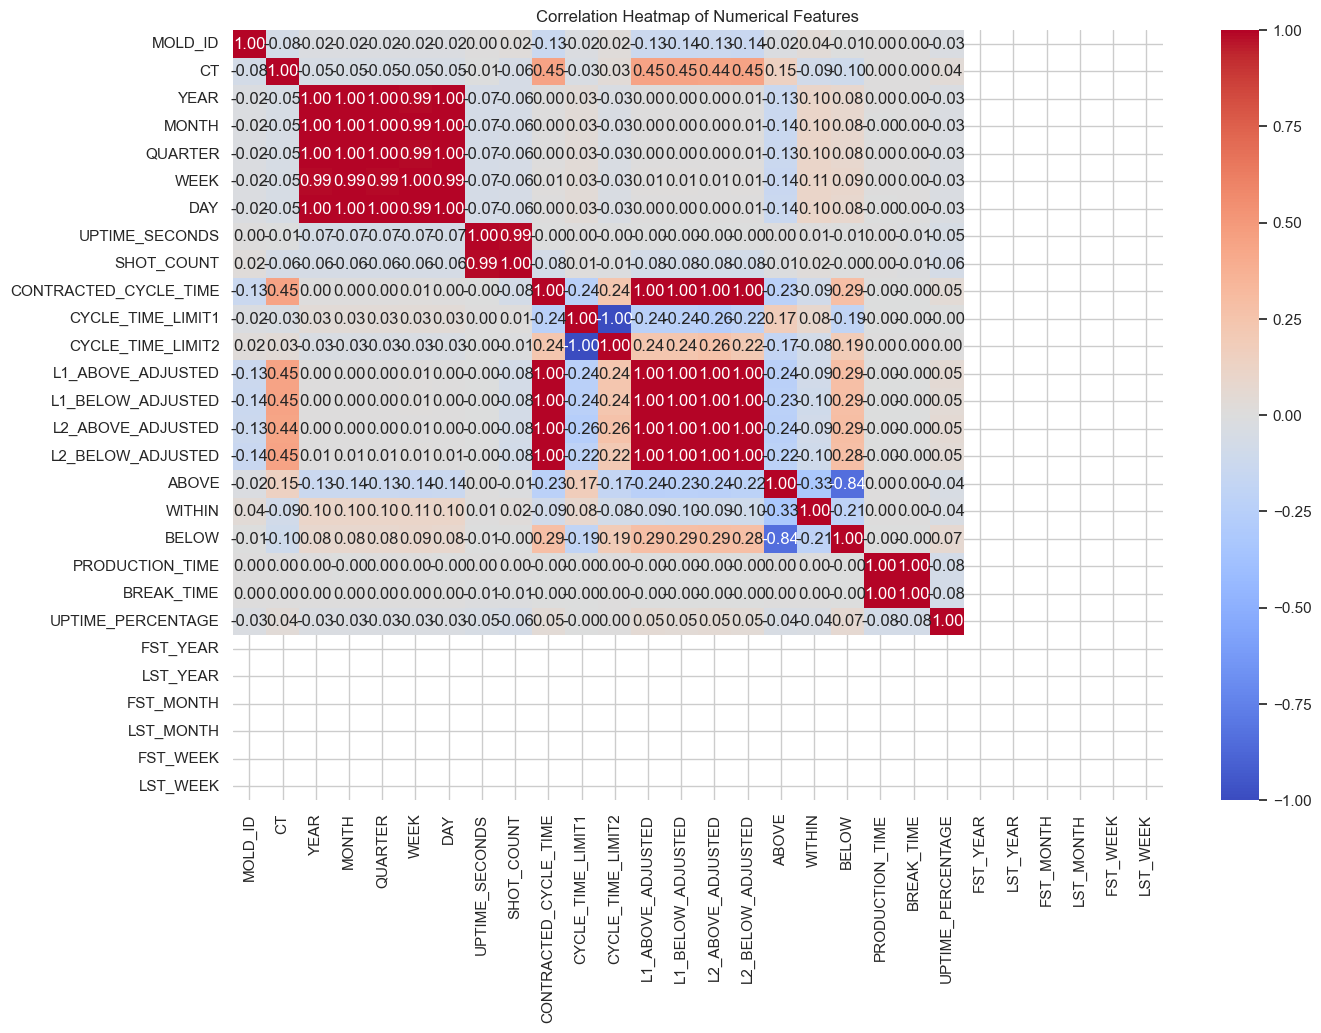

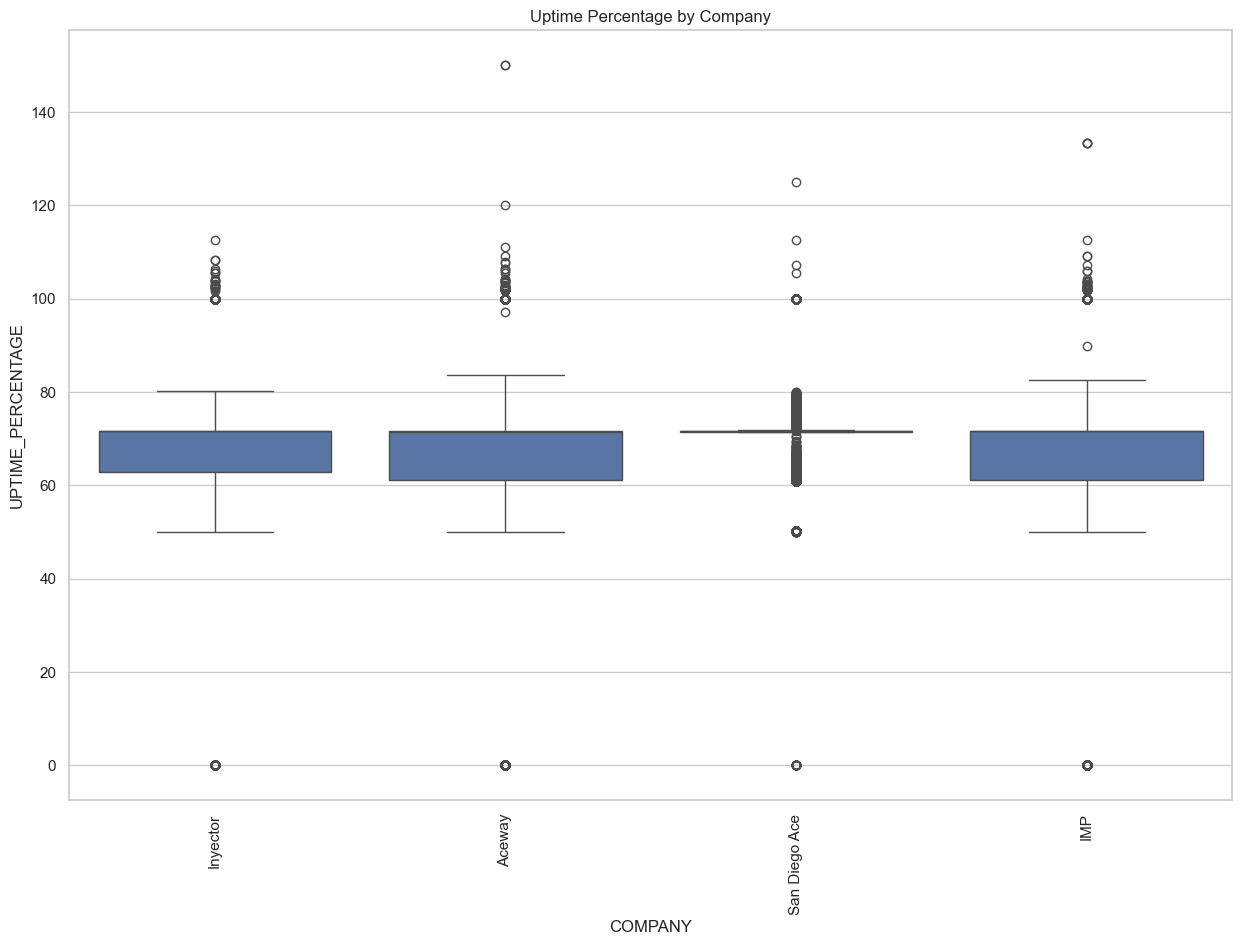

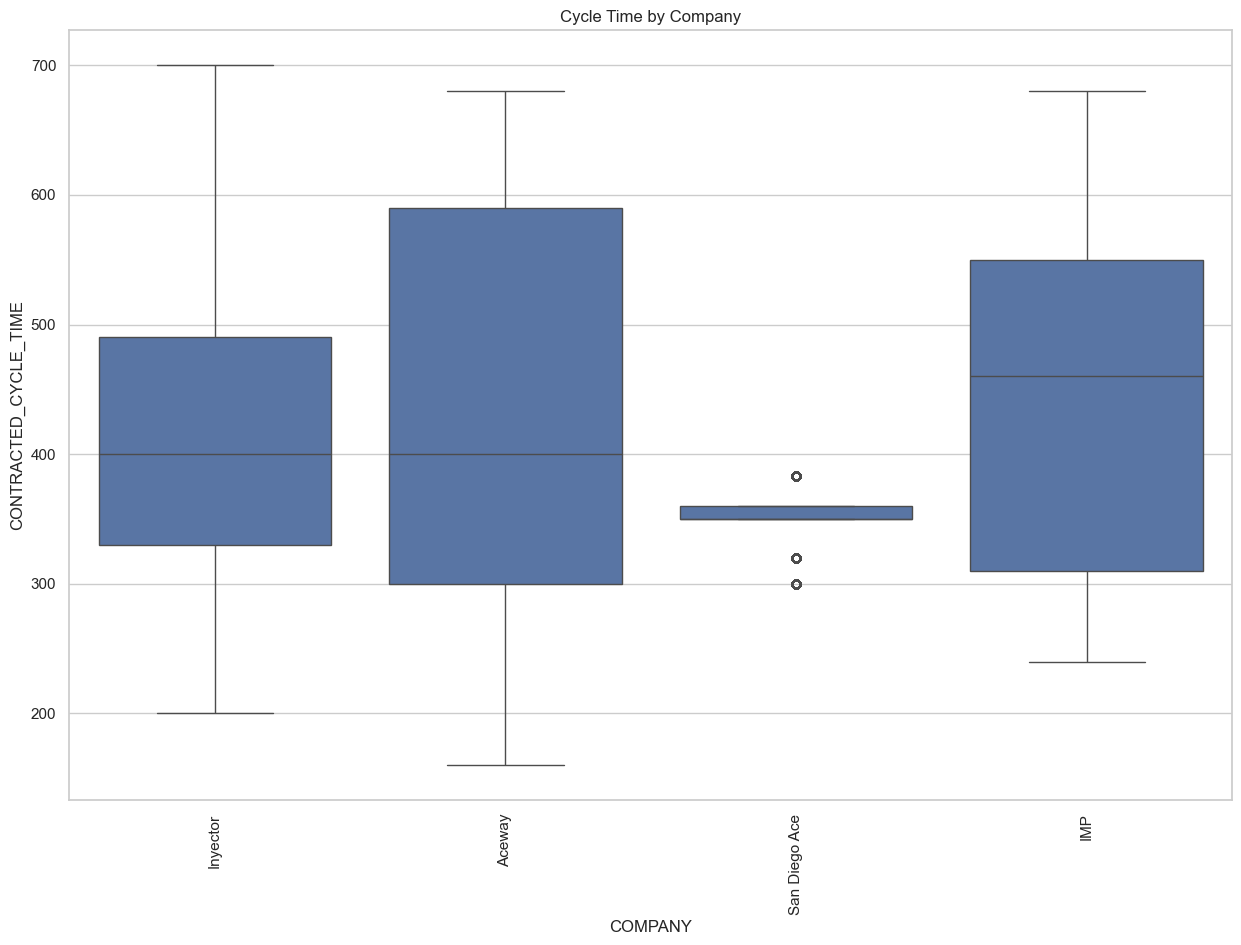

In [5]:
# EDA

import matplotlib.pyplot as plt 
import seaborn as sns

sns.set(style="whitegrid")

# Plotting the numeric columns 
plt.figure(figsize=(15,10))
df_filtered[['UPTIME_PERCENTAGE', 'PRODUCTION_TIME', 'BREAK_TIME', 'SHOT_COUNT']].hist(bins=50, figsize=(15,10))
plt.suptitle("Numeric Columns Distribution", fontsize=20)
plt.show()

# Time series analysis - plotting the uptime percentage over time (we will use fst and lst here)
plt.figure(figsize=(15,10)) 
df_filtered.groupby('FST_DATE')['UPTIME_PERCENTAGE'].mean().plot(kind='line')
plt.title('Uptime Percentage over Time')
plt.xlabel('Date')
plt.ylabel('Uptime Percentage')
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap of numerical features
# Selecting only numeric columns for correlation
numeric_df = df_filtered.select_dtypes(include=['number'])

plt.figure(figsize=(15,10))
corr_matrix = numeric_df.corr()  # Calculate correlation matrix for numeric columns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Boxplot of production metrics by company 
plt.figure(figsize=(15,10))
sns.boxplot(data=df, x=df_filtered['COMPANY'], y=df_filtered['UPTIME_PERCENTAGE'])
plt.xticks(rotation=90)
plt.title('Uptime Percentage by Company')
plt.show()

# Plot cycle time by company to compare performances 
plt.figure(figsize=(15,10))
sns.boxplot(data=df, x=df_filtered['COMPANY'], y=df_filtered['CONTRACTED_CYCLE_TIME'])
plt.xticks(rotation=90)
plt.title('Cycle Time by Company')
plt.show()


In [6]:
df_filtered.head()


,COMPANY,LOCATION,MOLD,MOLD_ID,CI,CT,FST,LST,YEAR,MONTH,...,BREAK_TIME,UPTIME_PERCENTAGE,FST_DATE,LST_DATE,FST_YEAR,LST_YEAR,FST_MONTH,LST_MONTH,FST_WEEK,LST_WEEK
9693,Inyector,Inyector,T127787,40551066,NCM2141I01106,396,NaT,NaT,2022,202208,...,6396,60.990485,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
9694,Inyector,Inyector,T127787,40551066,NCM2141I01106,396,NaT,NaT,2022,202208,...,6396,60.990485,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
9695,Inyector,Inyector,T127787,40551066,NCM2141I01106,396,NaT,NaT,2022,202208,...,6396,60.990485,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
9696,Inyector,Inyector,T127787,40551066,NCM2141I01106,396,NaT,NaT,2022,202208,...,6396,60.990485,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
9697,Inyector,Inyector,T127787,40551066,NCM2141I01106,396,NaT,NaT,2022,202208,...,6396,60.990485,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
import pandas as pd
import plotly.express as px

# Filter the DataFrame for the specified companies
companies = ['IMP', 'Inyector', 'Aceway', 'San Diego Ace']
df_filtered = df[df['COMPANY'].isin(companies)]

# Extract year and week from the 'WEEK' column (YYYYWW format)
df_filtered['YEAR_FROM_WEEK'] = df_filtered['WEEK'].astype(str).str[:4].astype(int)  # Extract the year part of the week column
df_filtered['WEEK_FROM_WEEK'] = df_filtered['WEEK'].astype(str).str[4:].astype(int)  # Extract the week number part of the week column

# Extract year and month from the 'MONTH' column (YYYYMM format)
df_filtered['YEAR_FROM_MONTH'] = df_filtered['MONTH'].astype(str).str[:4].astype(int)  # Extract the year part of the month column
df_filtered['MONTH_FROM_MONTH'] = df_filtered['MONTH'].astype(str).str[4:].astype(int)  # Extract the month part of the month column

# Filter data starting from 202301 (January 2023)
df_filtered = df_filtered[df_filtered['MONTH'] >= 202401]

# Weekly Aggregation by Year and Week
weekly_data = df_filtered.groupby(['COMPANY', 'YEAR_FROM_WEEK', 'WEEK_FROM_WEEK']).agg(
    avg_cycle_time=('CT', 'mean'),
    avg_uptime_percentage=('UPTIME_PERCENTAGE', 'mean'),
    total_run_time=('PRODUCTION_TIME', 'sum'),
    parts_made=('SHOT_COUNT', 'sum')
).reset_index()

# Monthly Aggregation by Year and Month
monthly_data = df_filtered.groupby(['COMPANY', 'YEAR_FROM_MONTH', 'MONTH_FROM_MONTH']).agg(
    avg_cycle_time=('CT', 'mean'),
    avg_uptime_percentage=('UPTIME_PERCENTAGE', 'mean'),
    total_run_time=('PRODUCTION_TIME', 'sum'),
    parts_made=('SHOT_COUNT', 'sum')
).reset_index()

# Create bar plot for Weekly Data, Faceted by Year
fig_weekly = px.bar(
    weekly_data,
    x='WEEK_FROM_WEEK',
    y='avg_cycle_time',
    color='COMPANY',
    barmode='group',
    facet_col='YEAR_FROM_WEEK',  # This will create separate bar plots for each year
    title='Weekly Average Cycle Time by Company (Starting from 2024)',
    labels={'avg_cycle_time': 'Average Cycle Time (s)', 'WEEK_FROM_WEEK': 'Week'},
    height=600  # Adjust the height of the plots for better visibility
)

# Show the weekly bar plot
fig_weekly.show()

# Create bar plot for Monthly Data, Faceted by Year
fig_monthly = px.bar(
    monthly_data,
    x='MONTH_FROM_MONTH',
    y='avg_cycle_time',
    color='COMPANY',
    barmode='group',
    facet_col='YEAR_FROM_MONTH',  # This will create separate bar plots for each year
    title='Monthly Average Cycle Time by Company (Starting from 2024)',
    labels={'avg_cycle_time': 'Average Cycle Time (s)', 'MONTH_FROM_MONTH': 'Month'},
    height=600  # Adjust the height of the plots for better visibility
)

# Show the monthly bar plot
fig_monthly.show()


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_12079/1372029970.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['YEAR_FROM_WEEK'] = df_filtered['WEEK'].astype(str).str[:4].astype(int)  # Extract the year part of the week column
/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_12079/1372029970.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['WEEK_FROM_WEEK'] = df_filtered['WEEK'].astype(str).str[4:].astype(int)  # Extract the week number part of the week

In [8]:
#lets look at the trend of uptime percentage over time 
from statsmodels.tsa.arima.model import ARIMA  # Correct import

df_time_series = df_filtered.groupby('FST_DATE')['UPTIME_PERCENTAGE'].mean()

#plotting
plt.figure(figsize=(15,10))
plt.title('Uptime Percentage over Time')
plt.xlabel('Date')
plt.ylabel('Uptime Percentage')
plt.xticks(rotation=45)
plt.show()

#time series forecasting with arima 



# Fit the ARIMA model
model = ARIMA(df_time_series, order=(5,1,0))    
model_fit = model.fit()

# Forecasting the next 30 days
forecast = model_fit.forecast(steps=30)

# Plotting the historical data and forecast
plt.figure(figsize=(15,10))
plt.plot(df_time_series.index, df_time_series, label='Historical data')
plt.plot(pd.date_range(start=df_time_series.index[-1], periods=30, freq='D'), forecast, label='Forecast', color='red')
plt.title('Uptime Percentage Forecasting')
plt.xlabel('Date')
plt.ylabel('Uptime Percentage')
plt.legend()
plt.show()





KeyError: 'FST_DATE'

In [ ]:
#nlp analysis

from wordcloud import WordCloud

#create a wordcloud for the company names
company_text = " ".join(df['COMPANY'].dropna().unique())
wordcloud = WordCloud(width = 800, height = 400, random_state=21, max_font_size=110,background_color='black').generate(company_text) 
plt.axis('off') 
plt.title('Company Names Wordcloud')
plt.imshow(wordcloud)
plt.show()

  

In [ ]:
# #deep learning model ( this is not complete)

# from keras.models import Sequential
# from keras.layers import Dense,LSTM,Dropout

# model = Sequential()
# model.add(LSTM(units= 50, return_sequences=True, input_shape=(X_train.shape[1],X_train.shape[2])))
# model.add(Dropout(0.2))
# model.add(LSTM(units=50, return_sequences=False))
# model.add(Dropout(0.2))
# model.add(Dense(unit=1))

# #compile and fit the model 

# model.compile(optimizer='adam', loss='mean_squared_error')
# model.fit(X_train, y_train, epochs=100, batch_size=32)      
